# HI 5304 — Python Data Science Toolkit for Health Informatics  
**Libraries:** pandas, NumPy, SciPy, matplotlib, seaborn, scikit-learn  
**Goal:** A hands-on tour of the most common analytics + visualization + modeling tools you’ll use in health informatics.

---

## What you’ll learn (at a glance)
- **NumPy**: fast numerical arrays and simulation
- **pandas**: tables (DataFrames), cleaning, joins, summaries
- **SciPy**: statistical tests and distributions
- **matplotlib**: foundational plotting
- **seaborn**: statistical visualization built on matplotlib
- **scikit-learn**: machine learning workflow (train/test split, model, metrics)

> This notebook uses **synthetic (fake)** health-style data so it runs anywhere.


## 1) Setup (imports + display options)

In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.linear_model import LogisticRegression

pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 120)

# Seaborn style defaults (optional)
sns.set_theme()

## 2) Create a synthetic health informatics dataset  
We’ll simulate a simple cohort with:
- Demographics: age, sex
- Clinical: systolic/diastolic, A1c, BMI
- Outcome: `uncontrolled_bp` (binary label for modeling)

In real work, these would come from EHR / claims / device data.


In [2]:
rng = np.random.default_rng(5304)
n = 400

age = rng.integers(35, 81, size=n)
sex = rng.choice(["F", "M"], size=n, p=[0.55, 0.45])

# Simulate BMI with some variability
bmi = np.clip(rng.normal(29, 5, size=n), 18, 55)

# Simulate A1c (glycemic control), loosely correlated with BMI and age
a1c = np.clip(5.4 + 0.03*(bmi-25) + 0.01*(age-50) + rng.normal(0, 0.4, size=n), 4.8, 12.5)

# Simulate BP with correlations
systolic = np.clip(115 + 0.6*(age-50) + 0.8*(bmi-25) + 4*(a1c-5.7) + rng.normal(0, 10, size=n), 90, 220)
diastolic = np.clip(70 + 0.25*(age-50) + 0.3*(bmi-25) + 1.5*(a1c-5.7) + rng.normal(0, 7, size=n), 50, 140)

df = pd.DataFrame({
    "age": age,
    "sex": sex,
    "bmi": bmi.round(1),
    "a1c": a1c.round(2),
    "systolic": systolic.round(0).astype(int),
    "diastolic": diastolic.round(0).astype(int),
})

# Define an outcome label (teaching rule): uncontrolled if >=140 or >=90
df["uncontrolled_bp"] = ((df["systolic"] >= 140) | (df["diastolic"] >= 90)).astype(int)

df.head()

,age,sex,bmi,a1c,systolic,diastolic,uncontrolled_bp
0,42,F,30.7,5.11,122,65,0
1,47,M,30.3,5.32,118,76,0
2,61,F,31.2,6.32,134,70,0
3,58,F,30.8,6.04,119,73,0
4,39,F,21.7,5.39,114,64,0


## 3) pandas basics: inspect, clean, summarize  
pandas is the go-to library for health informatics analytics because EHR/claims data is usually tabular.


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   age              400 non-null    int64  
 1   sex              400 non-null    str    
 2   bmi              400 non-null    float64
 3   a1c              400 non-null    float64
 4   systolic         400 non-null    int64  
 5   diastolic        400 non-null    int64  
 6   uncontrolled_bp  400 non-null    int64  
dtypes: float64(2), int64(4), str(1)
memory usage: 22.0 KB


In [4]:
df.describe()

,age,bmi,a1c,systolic,diastolic,uncontrolled_bp
count,400.000000,400.000000,400.000000,400.000000,400.000000,400.000000
mean,57.835000,28.785750,5.603675,121.915000,72.930000,0.130000
std,13.446367,4.835885,0.439223,13.600559,7.945939,0.336725
min,35.000000,18.000000,4.800000,90.000000,53.000000,0.000000
25%,46.000000,25.175000,5.300000,113.000000,67.000000,0.000000
50%,58.500000,28.850000,5.610000,122.000000,73.000000,0.000000
75%,70.000000,32.100000,5.910000,131.000000,78.000000,0.000000
max,80.000000,42.400000,6.940000,160.000000,97.000000,1.000000


### Example: create derived fields (feature engineering)

In [5]:
def bp_category(sys, dia):
    if sys < 120 and dia < 80:
        return "Normal"
    elif sys < 130 and dia < 80:
        return "Elevated"
    elif sys < 140 or dia < 90:
        return "HTN Stage 1"
    else:
        return "HTN Stage 2"

df["bp_category"] = [bp_category(s, d) for s, d in zip(df["systolic"], df["diastolic"])]

df["age_group"] = pd.cut(df["age"], bins=[34, 49, 64, 80], labels=["35–49", "50–64", "65–80"])

df[["age", "age_group", "systolic", "diastolic", "bp_category", "uncontrolled_bp"]].head()

,age,age_group,systolic,diastolic,bp_category,uncontrolled_bp
0,42,35–49,122,65,Elevated,0
1,47,35–49,118,76,Normal,0
2,61,50–64,134,70,HTN Stage 1,0
3,58,50–64,119,73,Normal,0
4,39,35–49,114,64,Normal,0


### Example: groupby summaries (clinic-style reporting)

In [6]:
summary_by_age = (df
    .groupby("age_group")
    .agg(
        n=("age", "size"),
        avg_systolic=("systolic", "mean"),
        avg_a1c=("a1c", "mean"),
        uncontrolled_rate=("uncontrolled_bp", "mean"),
    )
)

summary_by_age.round({"avg_systolic": 1, "avg_a1c": 2, "uncontrolled_rate": 3})

,n,avg_systolic,avg_a1c,uncontrolled_rate
age_group,,,,
35–49,125,112.7,5.46,0.024
50–64,132,121.1,5.57,0.061
65–80,143,130.7,5.76,0.287


## 4) NumPy: arrays + fast numeric operations  
NumPy is underneath pandas and many scientific tools. It is great for:
- Simulation
- Vectorized computations
- Efficient math on large arrays


In [7]:
arr = np.array([118, 122, 135, 142, 128, 150])  # example systolic readings
print("Array:", arr)
print("Mean:", arr.mean())
print("Std dev:", arr.std(ddof=1))
print("Min/Max:", arr.min(), arr.max())

# Vectorized transformation: "what if systolic dropped by 5 mmHg?"
improved = arr - 5
print("Improved readings:", improved)

Array: [118 122 135 142 128 150]
Mean: 132.5
Std dev: 12.19426094521517
Min/Max: 118 150
Improved readings: [113 117 130 137 123 145]


### NumPy example: simulation (measurement noise)

In [8]:
true_value = 130
noise = rng.normal(0, 8, size=1000)  # measurement noise
simulated = true_value + noise

print("Simulated mean:", simulated.mean().round(2))
print("Simulated std:", simulated.std(ddof=1).round(2))

Simulated mean: 129.78
Simulated std: 7.88


## 5) SciPy: statistics and hypothesis tests  
Example question:  
**Do average systolic values differ between females and males in this dataset?**  
We’ll run an independent-samples t-test (teaching demo).


In [9]:
female_sys = df.loc[df["sex"] == "F", "systolic"]
male_sys = df.loc[df["sex"] == "M", "systolic"]

t_stat, p_value = stats.ttest_ind(female_sys, male_sys, equal_var=False)  # Welch's t-test

print("Female mean systolic:", female_sys.mean().round(1))
print("Male mean systolic:", male_sys.mean().round(1))
print("t-statistic:", round(t_stat, 3))
print("p-value:", p_value)

Female mean systolic: 122.8
Male mean systolic: 120.9
t-statistic: 1.375
p-value: 0.16981215379544048


### SciPy example: correlation (A1c vs systolic)

In [10]:
r, p = stats.pearsonr(df["a1c"], df["systolic"])
print("Pearson r:", round(r, 3))
print("p-value:", p)

Pearson r: 0.447
p-value: 4.694286337801364e-21


## 6) matplotlib: foundational plotting  
We’ll plot:
- A histogram of systolic BP
- A line plot of average systolic by age group


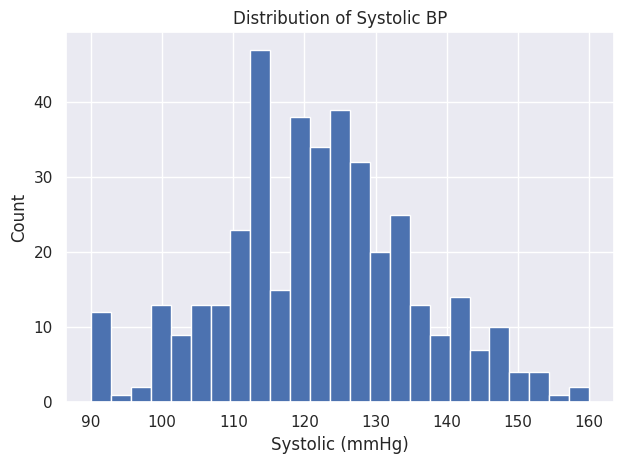

In [11]:
plt.figure()
plt.hist(df["systolic"], bins=25)
plt.title("Distribution of Systolic BP")
plt.xlabel("Systolic (mmHg)")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

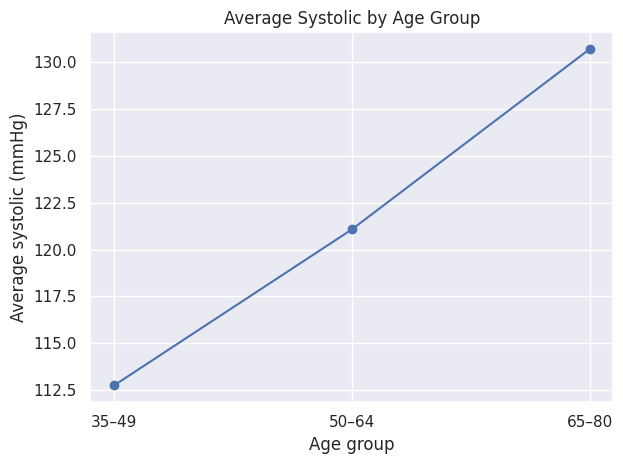

In [12]:
age_plot = df.groupby("age_group")["systolic"].mean().reset_index()

plt.figure()
plt.plot(age_plot["age_group"].astype(str), age_plot["systolic"], marker="o")
plt.title("Average Systolic by Age Group")
plt.xlabel("Age group")
plt.ylabel("Average systolic (mmHg)")
plt.tight_layout()
plt.show()

## 7) seaborn: statistical visualization  
We’ll create:
- Boxplot of systolic by sex
- Scatterplot of A1c vs systolic with a trend line


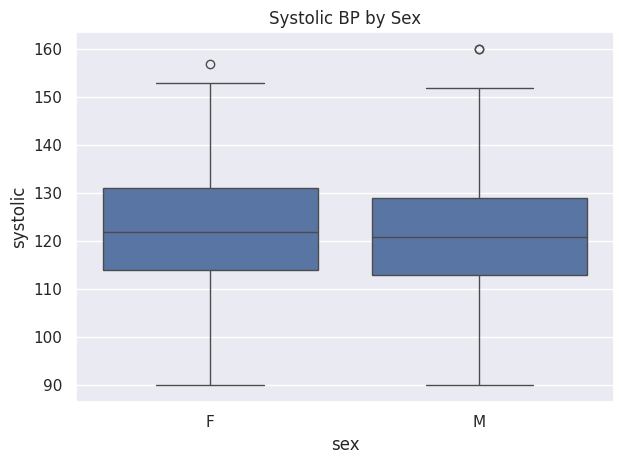

In [13]:
plt.figure()
sns.boxplot(data=df, x="sex", y="systolic")
plt.title("Systolic BP by Sex")
plt.tight_layout()
plt.show()

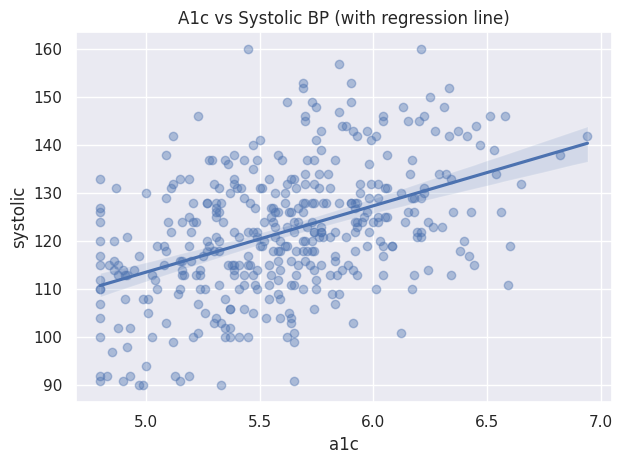

In [14]:
plt.figure()
sns.regplot(data=df, x="a1c", y="systolic", scatter_kws={"alpha": 0.4})
plt.title("A1c vs Systolic BP (with regression line)")
plt.tight_layout()
plt.show()

## 8) scikit-learn: ML workflow (classification)  
We’ll build a model to predict **uncontrolled_bp** using:
- age, BMI, A1c, sex

Workflow:
1. train/test split  
2. preprocessing (scale numeric + one-hot encode categorical)  
3. model training (Logistic Regression)  
4. evaluation (accuracy, report, confusion matrix)


In [15]:
X = df[["age", "sex", "bmi", "a1c"]]
y = df["uncontrolled_bp"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=5304, stratify=y
)

numeric_features = ["age", "bmi", "a1c"]
categorical_features = ["sex"]

preprocess = ColumnTransformer(
    transformers=[
        ("num", Pipeline(steps=[("scaler", StandardScaler())]), numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features),
    ]
)

clf = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", LogisticRegression(max_iter=300))
])

clf.fit(X_train, y_train)
pred = clf.predict(X_test)

print("Accuracy:", round(accuracy_score(y_test, pred), 3))
print("\nClassification report:")
print(classification_report(y_test, pred))

Accuracy: 0.858

Classification report:
              precision    recall  f1-score   support

           0       0.87      0.98      0.92       104
           1       0.33      0.06      0.11        16

    accuracy                           0.86       120
   macro avg       0.60      0.52      0.51       120
weighted avg       0.80      0.86      0.81       120



### Confusion matrix (table + heatmap)

In [16]:
cm = confusion_matrix(y_test, pred)
cm_df = pd.DataFrame(cm, index=["Actual 0", "Actual 1"], columns=["Pred 0", "Pred 1"])
cm_df

,Pred 0,Pred 1
Actual 0,102,2
Actual 1,15,1


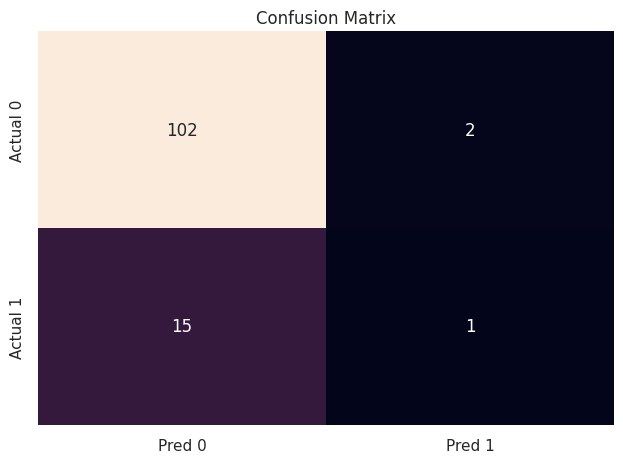

In [17]:
plt.figure()
sns.heatmap(cm_df, annot=True, fmt="d", cbar=False)
plt.title("Confusion Matrix")
plt.tight_layout()
plt.show()

## 9) Wrap-up: When to use which library  
- **NumPy**: fast math on arrays, simulation, vectorized operations  
- **pandas**: tabular data workflows (cleaning, joins, groupby summaries)  
- **SciPy**: classical statistics (tests, distributions, correlations)  
- **matplotlib**: fundamental plotting building blocks  
- **seaborn**: statistical visualization (boxplots, regression plots, heatmaps)  
- **scikit-learn**: ML pipelines, preprocessing, modeling, metrics

### Suggested next step for HI 5304
Replace the synthetic dataset with a real course CSV:
```python
df = pd.read_csv("your_file.csv")
```
Then repeat: inspect → clean → derive → summarize → visualize → (optional) model
